# Exploratory Data Analysis

This notebook performs exploratory data analysis on the Xente transaction dataset to understand data quality, distributions, relationships between variables, and potential preprocessing requirements for credit risk modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [22]:
REQUIRED_COLUMNS = [
    "TransactionId",
    "BatchId",
    "AccountId",
    "SubscriptionId",
    "CustomerId",
    "CurrencyCode",
    "CountryCode",
    "ProviderId",
    "ProductId",
    "ProductCategory",
    "ChannelId",
    "Amount",
    "Value",
    "TransactionStartTime",
    "PricingStrategy",
    "FraudResult"
]

In [23]:
def validate_columns(df, required_columns):
    """
    Ensure all expected columns exist.
    """

    missing = [
        col
        for col in required_columns
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing columns: {missing}"
        )

    print("Column validation passed.")

In [24]:
def get_dataset_overview(df):
    """
    Display dataset dimensions and types.
    """

    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

    return df.dtypes

In [25]:
def calculate_missing_values(df):
    """
    Calculate missing values.
    """

    return (
        df.isnull()
        .sum()
        .sort_values(ascending=False)
    )

In [26]:
def plot_correlation_heatmap(df, numerical_columns):
    """
    Plot correlation heatmap.
    """

    corr = df[numerical_columns].corr()

    plt.figure(figsize=(10,8))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm"
    )

    plt.title(
        "Correlation Heatmap"
    )

    plt.show()

In [38]:
assert len(df) > 0, "Dataset is empty"

In [39]:
assert (
    "CustomerId" in df.columns
), "CustomerId missing"

In [40]:
assert (
    "Amount" in df.columns
), "Amount missing"

In [41]:
assert (
    "FraudResult" in df.columns
), "FraudResult missing"

### 1. Dataset Overview

This section examines the structure of the dataset, including the number of observations, number of features, data types, and sample records.

In [27]:
df = pd.read_csv("../data/raw/data.csv")

In [29]:
validate_columns(
    df,
    REQUIRED_COLUMNS
)

Column validation passed.


In [30]:
get_dataset_overview(df)

Rows: 95662
Columns: 16


TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

In [28]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
df.shape

(95662, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

### 2. Summary Statistics

This section summarizes numerical and categorical variables to understand central tendency, variability, and feature characteristics.

In [5]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [21]:
df.describe(include="object")

C:\Users\Dataencoder\AppData\Local\Temp\ipykernel_13352\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935


### 3. Distribution of Numerical Features

Understanding feature distributions helps identify skewness, unusual patterns, and potential transformations required during feature engineering.

In [6]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

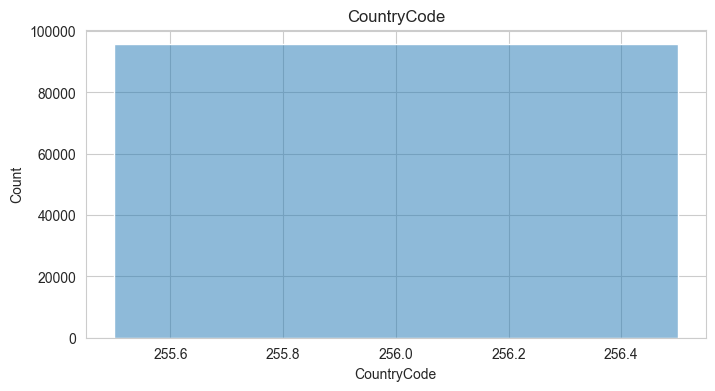

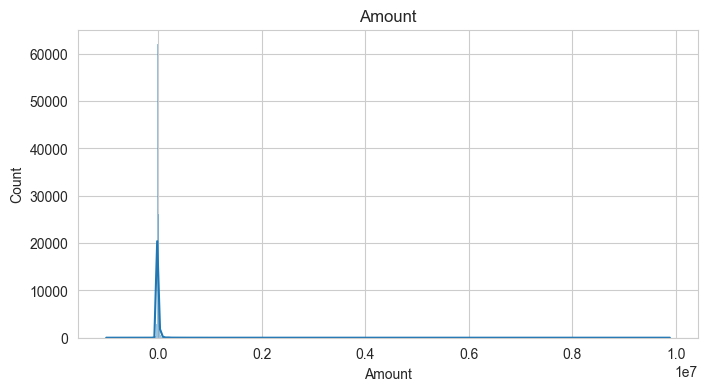

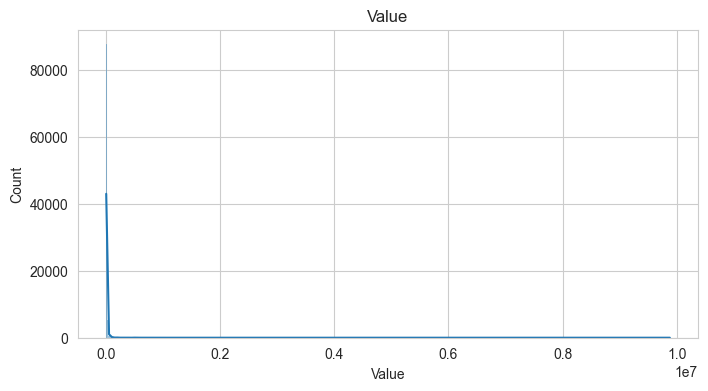

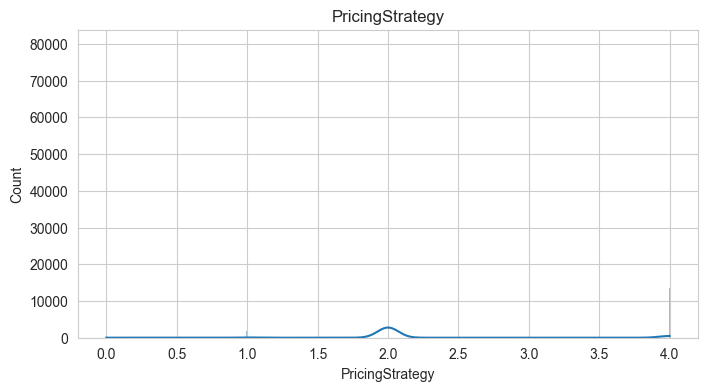

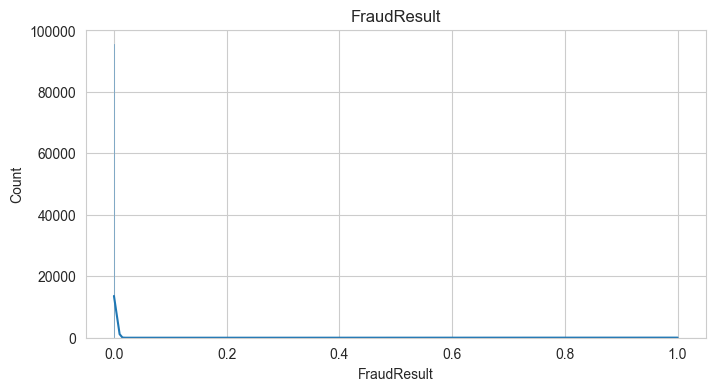

In [7]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

### 4. Distribution of Categorical Features

Categorical feature distributions help identify dominant categories, high-cardinality variables, and potential encoding requirements.


In [8]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

C:\Users\Dataencoder\AppData\Local\Temp\ipykernel_13352\2960911289.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='str')

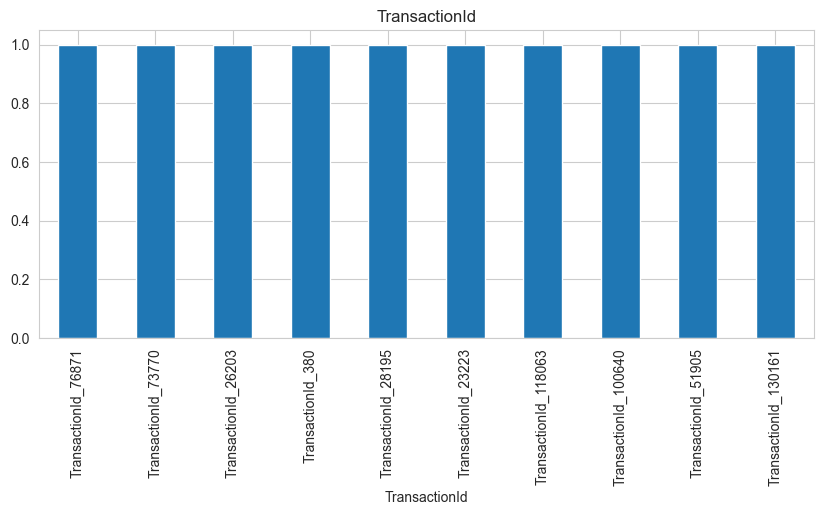

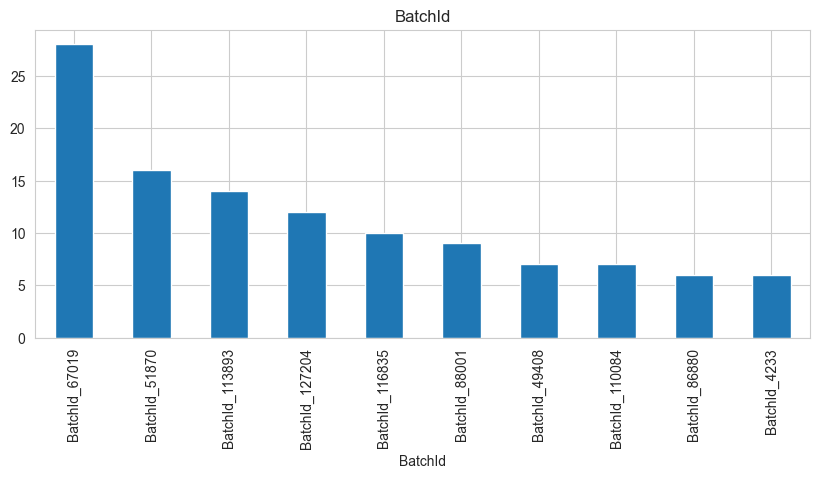

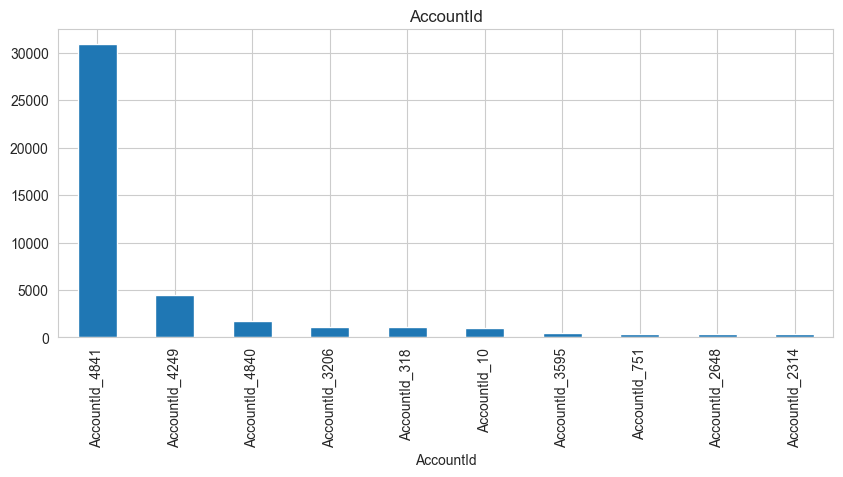

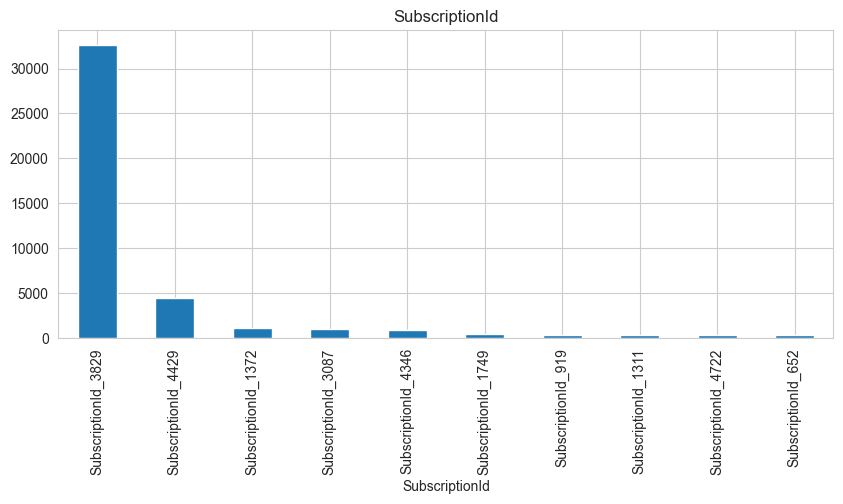

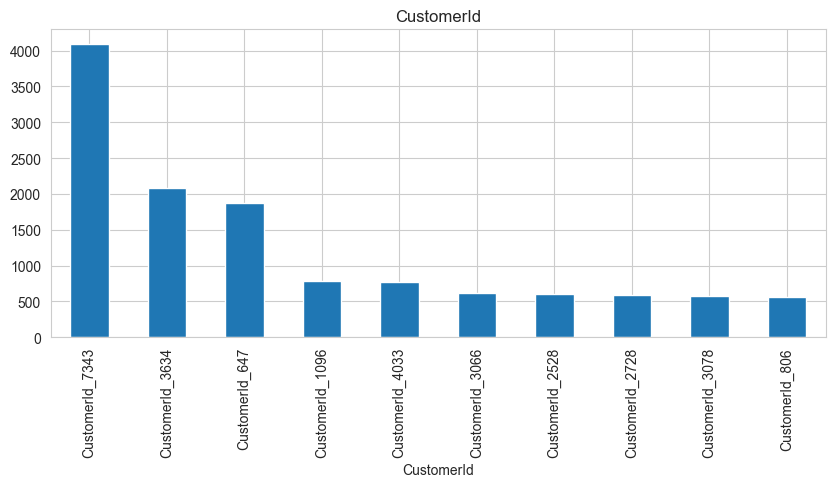

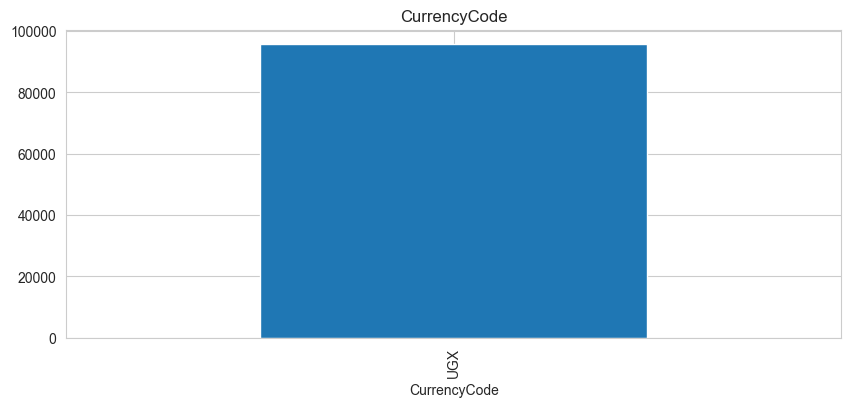

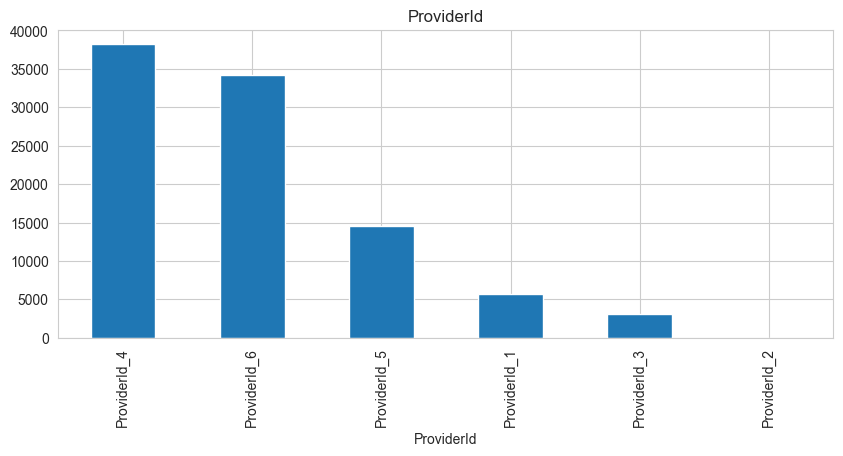

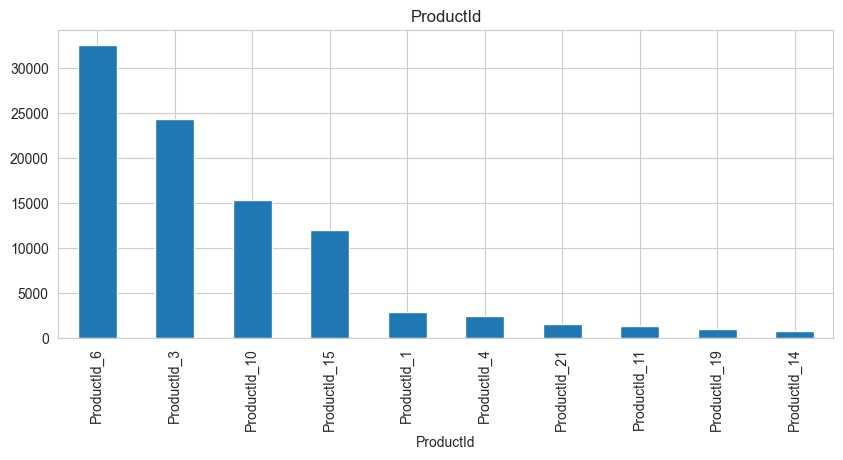

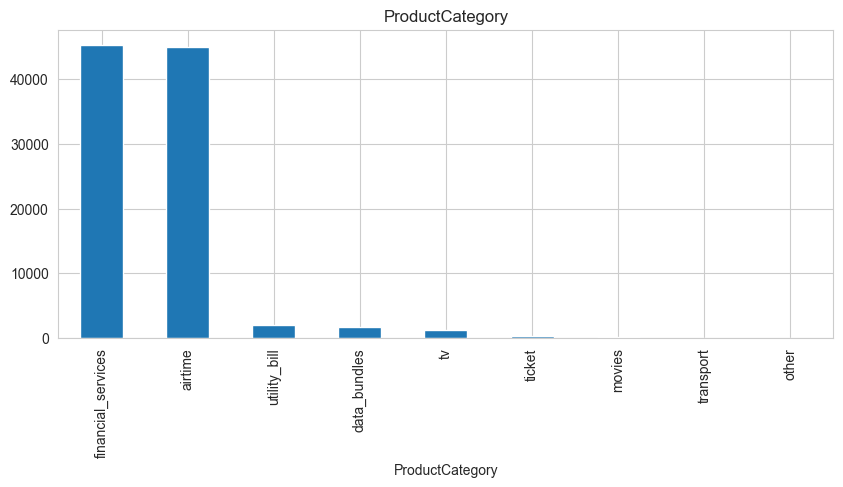

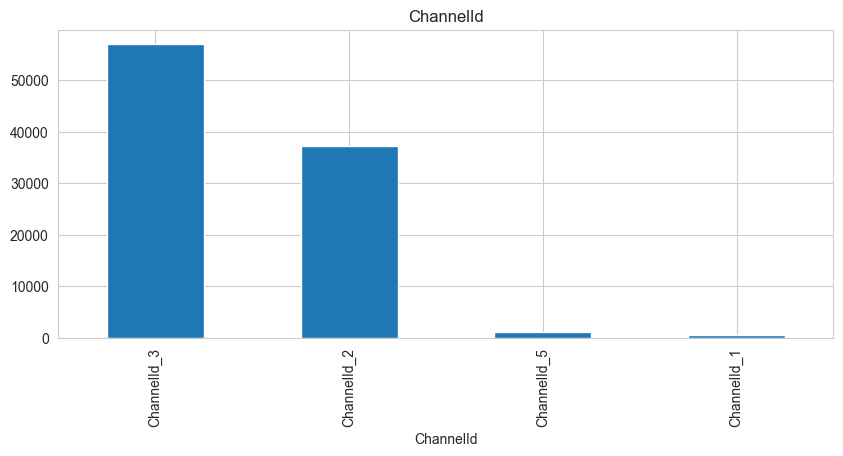

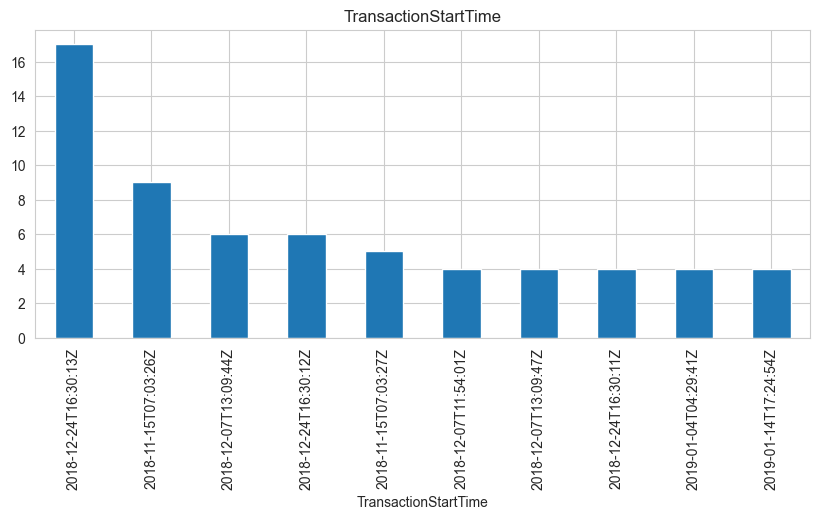

In [9]:
for col in cat_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(col)
    plt.show()

### 5. Correlation Analysis

This section examines relationships between numerical variables and identifies potentially redundant features.

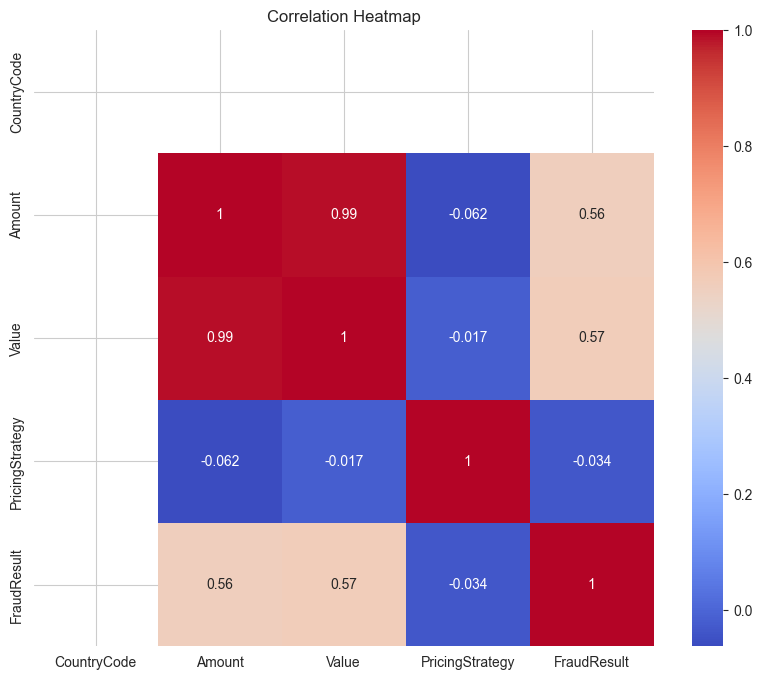

In [35]:
plot_correlation_heatmap(
    df,
    num_cols
)

In [33]:
# corr = df[num_cols].corr()

In [34]:
# plt.figure(figsize=(10,8))
# sns.heatmap(corr, annot=True, cmap="coolwarm")
# plt.show()

### 6. Missing Value Analysis

This section evaluates data completeness and determines whether imputation strategies may be required.

In [36]:
calculate_missing_values(df)

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

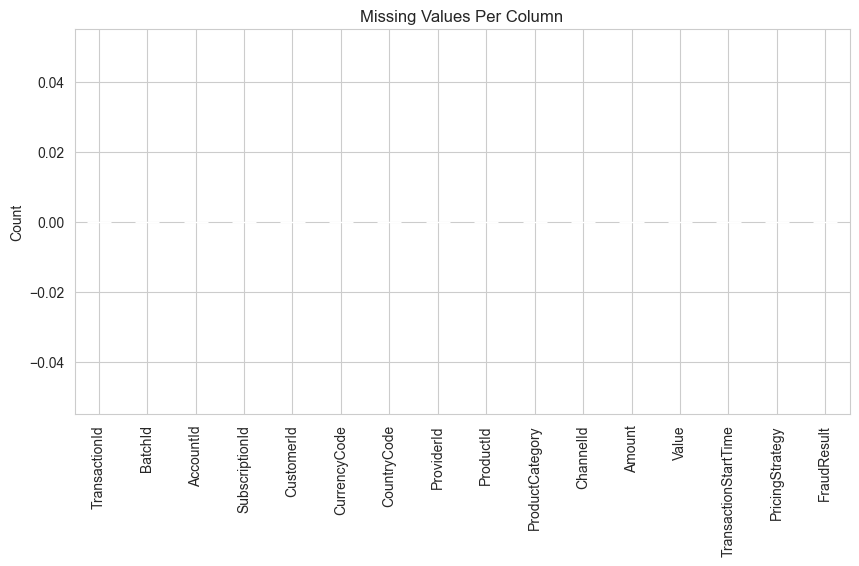

In [37]:
missing = calculate_missing_values(df).sort_values(ascending=False)

plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Missing Values Per Column")
plt.ylabel("Count")
plt.show()

In [14]:
df.duplicated().sum()

np.int64(0)

### 7. Outlier Detection

Boxplots are used to identify extreme observations that may affect model training.

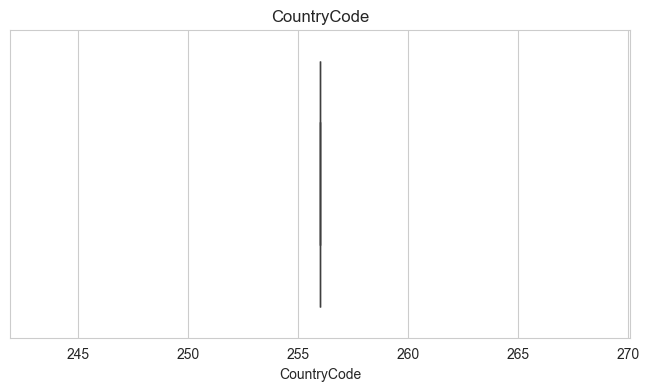

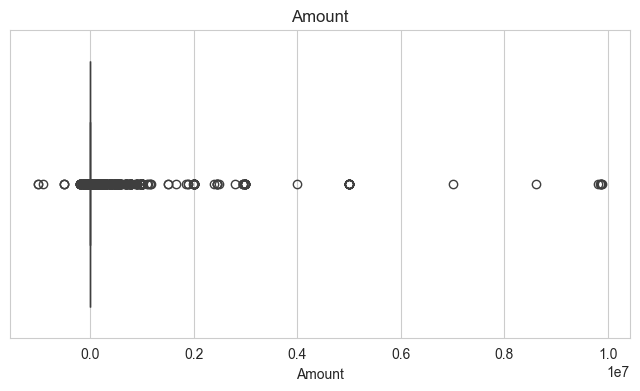

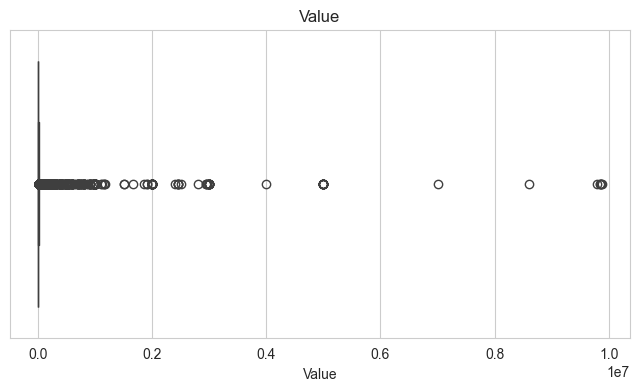

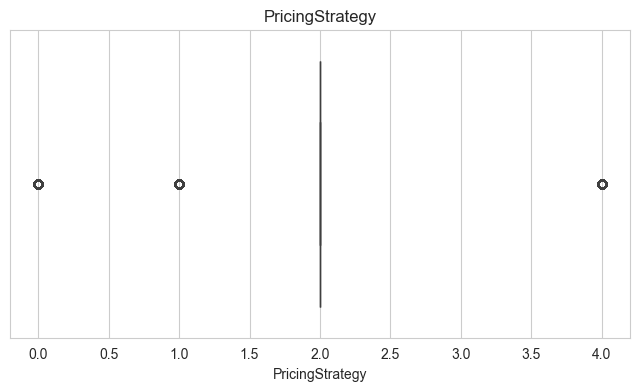

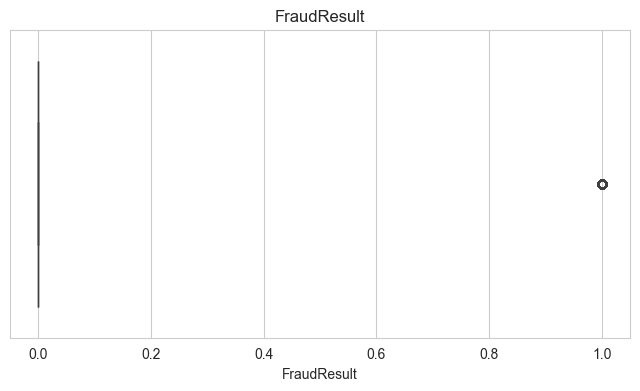

In [16]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### 8. Key Insights

The following observations summarize the most important findings from the exploratory analysis.

In [17]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

In [18]:
df["Hour"] = df["TransactionStartTime"].dt.hour
df["Day"] = df["TransactionStartTime"].dt.day
df["Month"] = df["TransactionStartTime"].dt.month

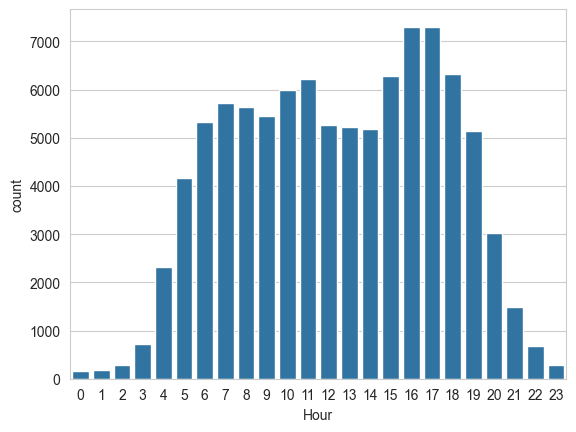

In [19]:
sns.countplot(x=df["Hour"])
plt.show()

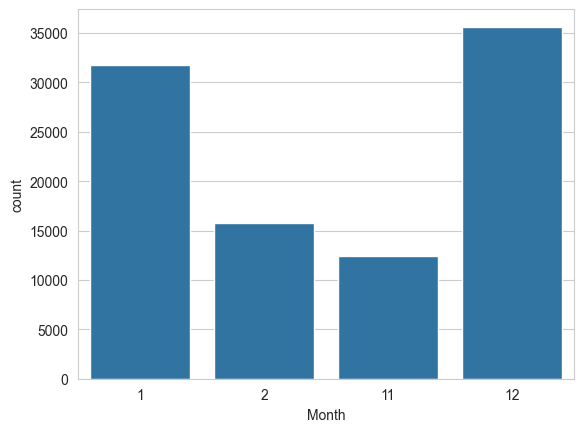

In [20]:
sns.countplot(x=df["Month"])
plt.show()

# EDA Conclusion

The exploratory analysis revealed that:

1. Transaction values are highly skewed.
2. Significant outliers exist in Amount and Value.
3. Amount and Value are strongly correlated.
4. Several categorical variables contain high-cardinality identifiers.
5. No missing values were detected.
6. Customer activity varies by time period, suggesting temporal features may be useful.

Implications for Feature Engineering:

- Numerical features may require scaling.
- Outliers should be carefully considered before modeling.
- High-cardinality categorical variables will require encoding.
- Temporal features should be extracted from TransactionStartTime.
- Correlated features will be reviewed during feature selection.